Import libraries and load dataset

In [15]:
import pandas as pd
from math import log2
df = pd.read_csv("BigMartSalesPrediction_Train.csv")
print(df.head())
print(df.shape)

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Medium               Tier

Dataset information

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB
None


Check missing values

In [3]:
print(df.isnull().sum())

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


Check duplicate values

In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Remove unnecessary columns

In [5]:
df = df.drop(
    ["Item_Identifier", "Outlet_Identifier"],
    axis=1
)

print(df.columns)
print(df.shape)

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')
(8523, 10)


Check Item Weight skewness

In [6]:
df["Item_Weight"].skew()

np.float64(0.08242620912212255)

Fill missing values

In [7]:
df["Item_Weight"] = df["Item_Weight"].fillna(
    df["Item_Weight"].median()
)
df["Outlet_Size"] = df["Outlet_Size"].fillna(
    df["Outlet_Size"].mode()[0]
)
print(df.isnull().sum())

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


Convert numerical columns into categories

In [8]:
numerical_columns = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year"
]
for column in numerical_columns:
    df[column] = pd.qcut(
        df[column],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    )
print(df.head())

  Item_Weight Item_Fat_Content Item_Visibility              Item_Type  \
0         Low          Low Fat             Low                  Dairy   
1         Low          Regular             Low            Soft Drinks   
2        High          Low Fat             Low                   Meat   
3        High          Regular             Low  Fruits and Vegetables   
4         Low          Low Fat             Low              Household   

  Item_MRP Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0     High                    Medium      Medium               Tier 1   
1      Low                      High      Medium               Tier 3   
2   Medium                    Medium      Medium               Tier 1   
3     High                    Medium      Medium               Tier 3   
4      Low                       Low        High               Tier 3   

         Outlet_Type  Item_Outlet_Sales  
0  Supermarket Type1          3735.1380  
1  Supermarket Type2           443.422

Convert target variable into categories

In [9]:
df["Item_Outlet_Sales"] = pd.qcut(
    df["Item_Outlet_Sales"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)
print(df["Item_Outlet_Sales"].value_counts())

Item_Outlet_Sales
Low       2845
High      2840
Medium    2838
Name: count, dtype: int64


Convert object columns to category

In [10]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns
for column in categorical_columns:
    df[column] = df[column].astype("category")
print(df.dtypes)

Item_Weight                  category
Item_Fat_Content             category
Item_Visibility              category
Item_Type                    category
Item_MRP                     category
Outlet_Establishment_Year    category
Outlet_Size                  category
Outlet_Location_Type         category
Outlet_Type                  category
Item_Outlet_Sales            category
dtype: object


Remove unused categories

In [11]:
for column in df.columns:
    if df[column].dtype.name == "category":
        df[column] = df[column].cat.remove_unused_categories()
print(df.dtypes)

Item_Weight                  category
Item_Fat_Content             category
Item_Visibility              category
Item_Type                    category
Item_MRP                     category
Outlet_Establishment_Year    category
Outlet_Size                  category
Outlet_Location_Type         category
Outlet_Type                  category
Item_Outlet_Sales            category
dtype: object


Define target

In [12]:
target = "Item_Outlet_Sales"

Implement ID3 using sklearn

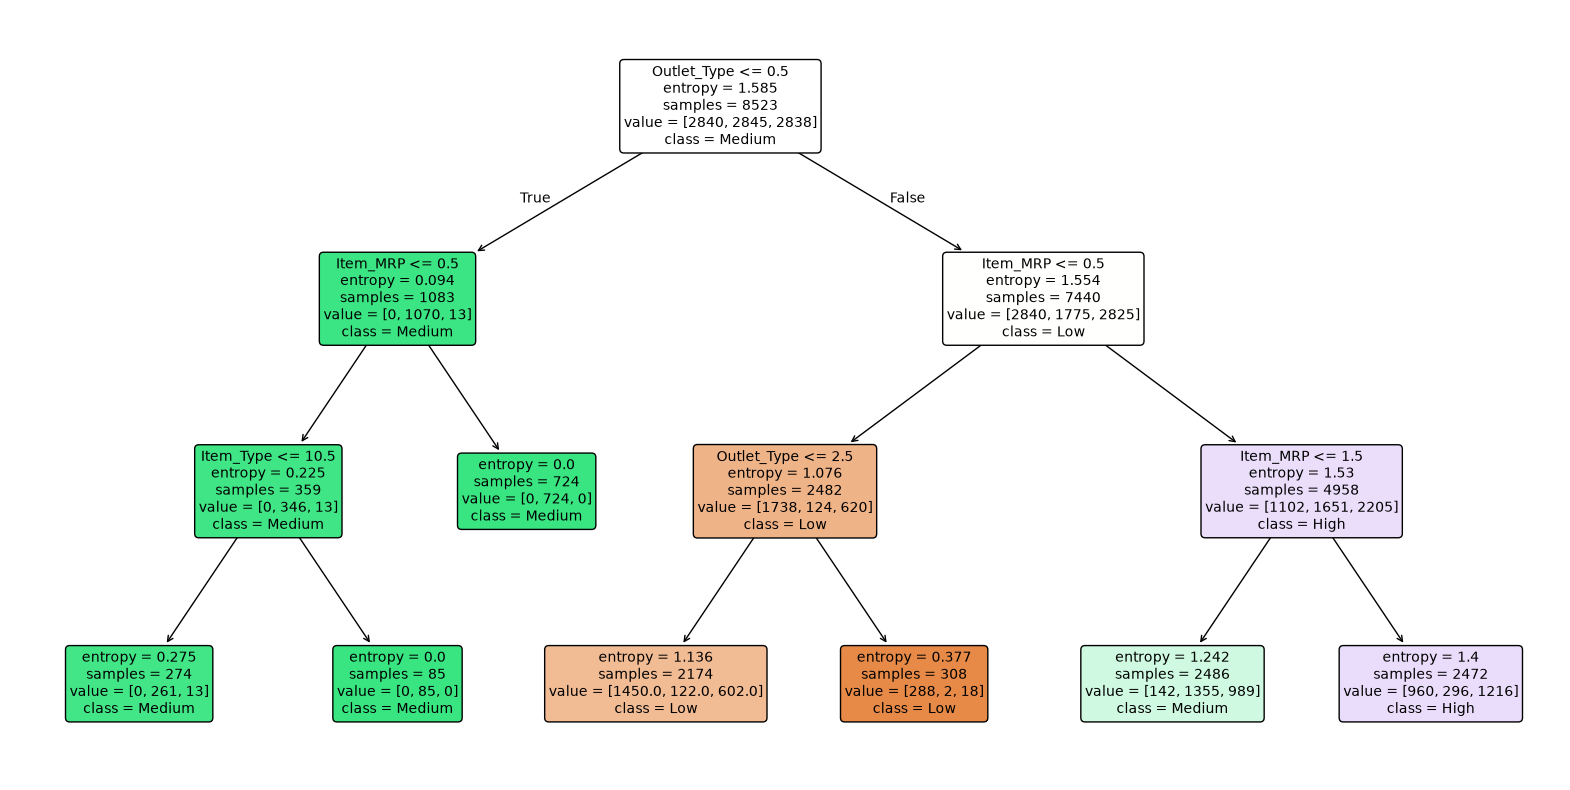

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
data = df.copy()
encoder = LabelEncoder()
for column in data.columns:
    data[column] = encoder.fit_transform(data[column])
X = data.drop("Item_Outlet_Sales", axis=1)
y = data["Item_Outlet_Sales"]
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
model.fit(X, y)
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()